In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import json

In [2]:
def context_window(fea,left,right):
    N_row=fea.shape[0]
    N_fea=fea.shape[1]
    frames = np.empty((N_row-left-right, N_fea*(left+right+1)))
    for frame_index in range(left,N_row-right):
        right_context=fea[frame_index+1:frame_index+right+1].flatten() # right context
        left_context=fea[frame_index-left:frame_index].flatten() # left context
        current_frame=np.concatenate([left_context,fea[frame_index],right_context])
        frames[frame_index-left]=current_frame
    return frames

In [9]:
with open("segmentation_results_12dim_dev.json") as f:
    results = json.load(f)

print(results)

{'FCAL1_SI1403': {'prediction': [11, 19, 24, 43, 52, 59, 66, 73, 84, 94, 97, 102, 110, 116, 122, 139, 142, 159, 161, 171, 181, 191, 198, 204, 216, 221, 232, 237, 245, 249, 253, 257, 264, 271, 275, 280, 286, 293, 299, 304, 312, 322, 328, 332, 341, 352, 359, 372, 382, 389, 393, 404, 415, 424, 435, 445, 450, 473], 'matches': 38, 'match_pct': 65.52, 'inserts': 20, 'insert_pct': 34.48, 'deletes': 20, 'del_pct': 34.48, 'consec_matches': 50.88}, 'FCAL1_SI773': {'prediction': [4, 13, 20, 27, 31, 41, 47, 56, 59, 62, 70, 82, 86, 91, 100, 103, 107, 111, 116, 120, 138, 151, 165, 169, 175, 185, 191, 202, 210, 221, 227, 231, 237, 246, 257, 266, 278, 281], 'matches': 26, 'match_pct': 68.42, 'inserts': 12, 'insert_pct': 31.58, 'deletes': 12, 'del_pct': 31.58, 'consec_matches': 54.05}, 'FCAL1_SX233': {'prediction': [10, 13, 19, 36, 45, 53, 74, 80, 91, 95, 104, 113, 125, 133, 139, 151, 155, 163, 175, 180, 194, 203, 208, 232, 238, 245], 'matches': 19, 'match_pct': 73.08, 'inserts': 7, 'insert_pct': 26.92

In [10]:
import numpy as np
from collections import defaultdict

with open("dev.json") as f:
    frames = json.load(f)

segment_centroids = []
kmeans_centroids = {}

for result in results:
    endpoints = results[result]["prediction"]
    T = frames[result]["feat_shape"][0]
    
    while endpoints[0] < 5:
        endpoints.pop(0)
    while endpoints[-1] > T - 5:
        endpoints.pop()
        
    endpoints = [endpoint - 5 for endpoint in endpoints]
    
    feat39 = np.array(frames[result]["features"])
    features = context_window(feat39, 5, 5)
    centroids = []
    start = 0
    # print(len(endpoints))

    for endpoint in endpoints:
        centroids.append(np.mean(features[start : endpoint + 1], axis=0))
        start = endpoint + 1

    centroids = centroids[1:]
    segment_centroids.extend(centroids)

centroids = np.load('kmeans_centroids_429dim_12dimsegments.npy')

cluster_dict = defaultdict(list)

for i, vec in enumerate(segment_centroids):
    distances = np.linalg.norm(centroids - vec, axis=1)
    cluster_idx = np.argmin(distances)
    cluster_dict[cluster_idx].append(vec)

cluster_dict = dict(cluster_dict)

import pickle

with open('dev_12dim.pkl', 'wb') as f:
    pickle.dump(cluster_dict, f)

In [3]:
with open('alignments_train.json', 'r') as f:
    results = json.load(f)

for r in results:
    results[r] = {'prediction':results[r]}

In [4]:
with open("train.json") as f:
    frames = json.load(f)

segment_centroids = []
kmeans_centroids = {}

for result in results:
    endpoints = results[result]["prediction"]
    T = frames[result]["feat_shape"][0]
    
    while endpoints[0] < 5:
        endpoints.pop(0)
    while endpoints[-1] > T - 5:
        endpoints.pop()
        
    endpoints = [endpoint - 5 for endpoint in endpoints]
        
    feat39 = np.array(frames[result]["features"])
    features = context_window(feat39, 5, 5)
    centroids = []
    start = 0
    # print(len(endpoints))

    for endpoint in endpoints:
        centroids.append(np.mean(features[start : endpoint + 1], axis=0))
        start = endpoint + 1

    centroids = centroids[1:]
    segment_centroids.extend(centroids)
    
    # segment_centroids[result] = centroids
    # print(len(centroids))
    # print([centroid.shape for centroid in centroids])
kmeans = KMeans(n_clusters=39)
kmeans.fit(segment_centroids)
# kmeans.cluster_centers_

,n_clusters,39
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [7]:
from collections import defaultdict

# Assuming you have these from KMeans
# segment_centroids: your original data
# kmeans.labels_: cluster labels

cluster_dict = defaultdict(list)

for idx, label in enumerate(kmeans.labels_):
    cluster_dict[label].append(segment_centroids[idx])

# If you want a normal dict instead of defaultdict
cluster_dict = dict(cluster_dict)

In [8]:
arr = np.array(kmeans.cluster_centers_)
# np.save('kmeans_centroids_429dim_12dimsegments.npy', arr)
np.save('gmm_hmm_clusters.npy', arr)

In [9]:
import pickle

with open('train.pkl', 'wb') as f:
    pickle.dump(cluster_dict, f)

In [7]:
arr.shape

(40, 429)

In [8]:
kmeans.cluster_centers_

array([[ 5.44755140e+00,  2.11229722e+01, -9.04016329e+00, ...,
        -1.17671410e-01, -3.61927395e-02,  5.99105264e-02],
       [ 9.19194088e+00,  7.19376900e+00, -5.94353428e+00, ...,
        -4.12380071e-02,  6.91539127e-02,  3.16913625e-02],
       [-8.77516674e+00, -1.44299863e+01,  4.52360926e+00, ...,
        -1.99694877e-01, -9.87718919e-02,  2.36309439e-01],
       ...,
       [ 6.35127984e+00,  2.75121262e+00,  4.51973209e+00, ...,
         6.34265168e-02,  1.86123085e-02,  4.48184336e-02],
       [-1.22586107e+01, -1.00554966e+01,  2.41818801e+00, ...,
        -1.55534483e-02, -1.23537751e-02, -1.18024503e-02],
       [ 2.32567599e+00, -3.28346532e+01,  1.24648971e+01, ...,
        -6.89231504e-02, -7.25434613e-02,  2.08485337e-01]])

In [5]:
# Data-preprocessing: Standardizing the data
from sklearn.preprocessing import StandardScaler

standardized_data = StandardScaler().fit_transform(segment_centroids)
print(standardized_data.shape)


(167116, 429)


In [10]:
%pip install colorcet

You should consider upgrading via the '/home/dhanya/anaconda3/envs/ASR/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_834624/4170704716.py:28: UserWarning: The palette list has more values (40) than needed (39), which may not be intended.
  sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2', hue="label", palette=palette)


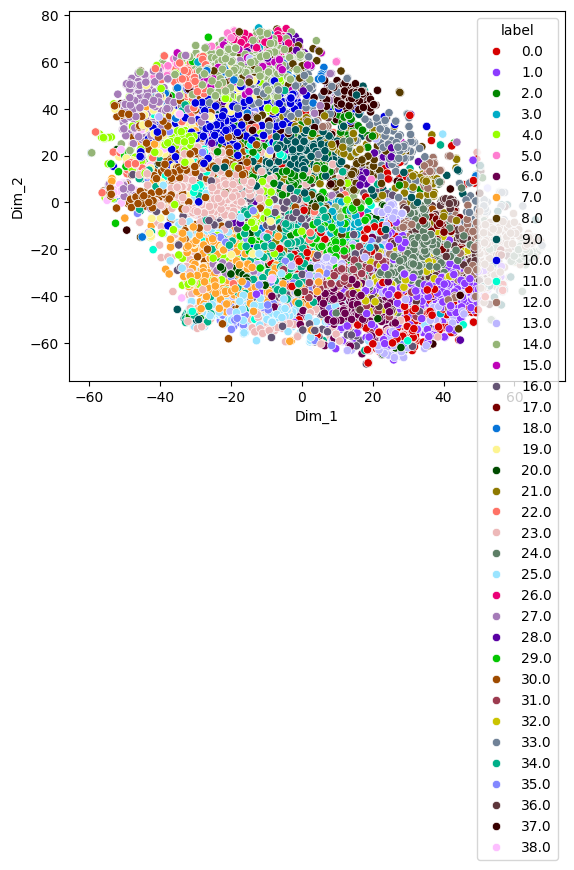

In [6]:
import seaborn as sns
# Picking the top 1000 points as TSNE
import colorcet as cc

# takes a lot of time for 15K points
data_1000 = standardized_data[0:10000, :]
labels_1000 = kmeans.labels_[0:10000]

model = TSNE(n_components = 2, random_state = 0)
# configuring the parameters
# the number of components = 2
# default perplexity = 30
# default learning rate = 200
# default Maximum number of iterations
# for the optimization = 1000

tsne_data = model.fit_transform(data_1000)

# creating a new data frame which
# help us in plotting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T
tsne_df = pd.DataFrame(data = tsne_data,
	columns =("Dim_1", "Dim_2", "label"))

# Plotting the result of tsne
palette = sns.color_palette(cc.glasbey, n_colors=40)

sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2', hue="label", palette=palette)
plt.show()


In [ ]:

sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2', hue="label", palette=palette, s=10)
plt.show()

In [3]:
# with open("train_segmentation_results.json") as f:
#     results = json.load(f)

# with open("test_segmentation_results.json") as f:
#     results1 = json.load(f)

# with open("dev_segmentation_results.json") as f:
#     results2 = json.load(f)


In [4]:
# results.update(results1)
# results.update(results2)

In [3]:
with open("train.json") as f:
    frames = json.load(f)
with open("segmentation_results.json") as f:
    results = json.load(f)

In [20]:
segment_centroids = []
kmeans_centroids = {}

for result in results:
    if result in frames:
        endpoints = results[result]["prediction"]
        features = frames[result]["features"]
        centroids = []
        start = 0
        # print(len(endpoints))
    
        for endpoint in endpoints:
            centroids.append(np.mean(features[start : endpoint + 1], axis=0))
            start = endpoint + 1
    
        centroids = centroids[1:]
        segment_centroids.extend(centroids)


/home/shwetha/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/shwetha/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [3]:
with open('alignments_train.json', 'r') as f:
    results = json.load(f)

In [9]:
print(len(results['FAEM0_SA1']), len(frames['FAEM0_SA1']['segment_boundary']))

38 41


In [5]:
with open("train.json") as f:
    frames = json.load(f)


In [7]:
frames['FAEM0_SA1']['segment_boundary']

[0,
 14,
 25,
 33,
 40,
 48,
 52,
 56,
 65,
 73,
 74,
 84,
 90,
 96,
 98,
 112,
 124,
 138,
 143,
 148,
 154,
 158,
 163,
 172,
 184,
 190,
 199,
 214,
 224,
 230,
 234,
 244,
 246,
 257,
 270,
 283,
 288,
 301,
 310,
 320,
 336]

In [15]:
segment_centroids = []
kmeans_centroids = {}

for result in results:
    if result in frames:
        endpoints = results[result]["prediction"]
        features = frames[result]["features"]
        centroids = []
        start = 0
        # print(len(endpoints))
    
        for endpoint in endpoints:
            centroids.append(np.mean(features[start : endpoint + 1], axis=0))
            start = endpoint + 1
    
        centroids = centroids[1:]
        segment_centroids.extend(centroids)
        
    # segment_centroids[result] = centroids
    # print(len(centroids))
    # print([centroid.shape for centroid in centroids])

segment_centroids = [segment_centroid for segment_centroid in segment_centroids if segment_centroid.shape == (39,)]

kmeans = KMeans(n_clusters=40)
kmeans.fit(segment_centroids)
# kmeans.cluster_centers_

/home/shwetha/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/shwetha/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/shwetha/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=40)

In [14]:
[segment_centroid.shape == (39,) for segment_centroid in segment_centroids].count(False)

22

In [16]:
# Data-preprocessing: Standardizing the data
from sklearn.preprocessing import StandardScaler

standardized_data = StandardScaler().fit_transform(segment_centroids)
print(standardized_data.shape)

(181678, 39)


In [17]:
import seaborn as sns
# Picking the top 1000 points as TSNE
import colorcet as cc

# takes a lot of time for 15K points
data_1000 = standardized_data[0:10000, :]
labels_1000 = kmeans.labels_[0:10000]

model = TSNE(n_components = 2, random_state = 0)
# configuring the parameters
# the number of components = 2
# default perplexity = 30
# default learning rate = 200
# default Maximum number of iterations
# for the optimization = 1000

tsne_data = model.fit_transform(data_1000)

# creating a new data frame which
# help us in plotting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T
tsne_df = pd.DataFrame(data = tsne_data,
	columns =("Dim_1", "Dim_2", "label"))

# Plotting the result of tsne
palette = sns.color_palette(cc.glasbey, n_colors=40)



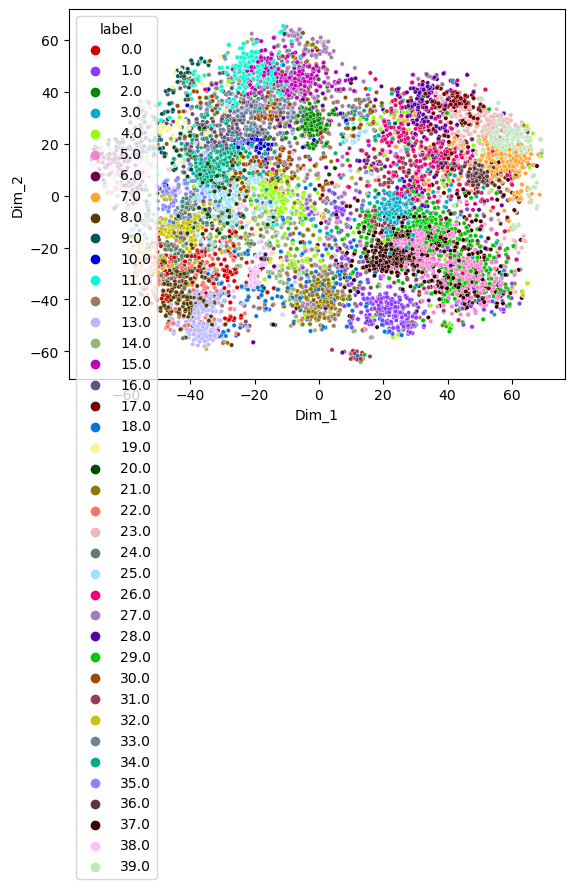

In [18]:
sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2', hue="label", palette=palette, s=10)
plt.show()

In [19]:
with open('train_kmeans_centroids_39_dim.json', 'w') as f:
    json.dump(kmeans.cluster_centers_.tolist(), f)